Import Libraries

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load dataset

In [4]:

df = pd.read_csv('Electronic_sales.csv')

Basic Info

In [3]:

df.shape

(20000, 15)

In [57]:
df.head()

,Customer_ID,Age,Gender,Loyalty_Member,Product_Type,SKU,Rating,Order_Status,Payment_Method,Total_Price,Unit_Price,Quantity,Purchase_Date,Shipping_Type,Add_on_Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,20-03-2024,Standard,40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,20-04-2024,Overnight,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,17-10-2023,Express,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,09-08-2024,Overnight,60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,21-05-2024,Express,35.56


In [5]:
df.tail()

,Customer_ID,Age,Gender,Loyalty_Member,Product_Type,SKU,Rating,Order_Status,Payment_Method,Total_Price,Unit_Price,Quantity,Purchase_Date,Shipping_Type,Add_on_Total
19995,19996,27,Female,No,Smartphone,SMP234,4,Completed,Bank Transfer,6838.08,1139.68,6,15-06-2024,Expedited,0.00
19996,19996,27,Female,Yes,Laptop,LTP123,4,Cancelled,Credit Card,2697.28,674.32,4,18-07-2024,Standard,0.00
19997,19996,27,Female,No,Headphones,HDP456,4,Completed,Bank Transfer,1805.90,361.18,5,26-08-2024,Standard,198.98
19998,19997,27,Male,No,Headphones,HDP456,1,Cancelled,Bank Transfer,2528.26,361.18,7,06-01-2024,Expedited,101.34
19999,19998,27,NaN,Yes,Laptop,LTP123,4,Completed,Bank Transfer,674.32,674.32,1,29-01-2024,Expedited,0.00


In [6]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Loyalty_Member', 'Product_Type', 'SKU',
       'Rating', 'Order_Status', 'Payment_Method', 'Total_Price', 'Unit_Price',
       'Quantity', 'Purchase_Date', 'Shipping_Type', 'Add_on_Total'],
      dtype='str')

In [7]:
df.dtypes

Customer_ID         int64
Age                 int64
Gender                str
Loyalty_Member        str
Product_Type          str
SKU                   str
Rating              int64
Order_Status          str
Payment_Method        str
Total_Price       float64
Unit_Price        float64
Quantity            int64
Purchase_Date         str
Shipping_Type         str
Add_on_Total      float64
dtype: object

Data Cleaning

In [8]:

df.dropna(subset=['Gender'], inplace=True)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'], dayfirst=True, errors='coerce')

In [11]:
df.dropna(subset=['Purchase_Date'], inplace=True)

In [13]:
df['Month'] = df['Purchase_Date'].dt.month
df['Hour']  = df['Purchase_Date'].dt.hour

In [14]:
df = df[df['Order_Status'] == 'Completed']

KPI

In [15]:

total_revenue        = df['Total_Price'].sum()
total_orders         = df['Customer_ID'].count()
avg_order_value      = df['Total_Price'].mean()
best_selling_product = df.groupby('Product_Type')['Quantity'].sum().idxmax()
top_revenue_product  = df.groupby('Product_Type')['Total_Price'].sum().idxmax()

In [16]:
print(total_revenue)
print(total_orders)
print(avg_order_value)
print(best_selling_product)
print(top_revenue_product)

42628941.25
13431
3173.9216178988904
Smartphone
Smartphone


EDA

In [17]:

monthly_sales = df.groupby('Month')['Total_Price'].sum().reset_index()
monthly_sales.columns = ['Month', 'Revenue']
monthly_sales

,Month,Revenue
0,1,4515603.49
1,2,3897250.16
2,3,4226126.65
3,4,4300323.69
4,5,4462915.20
5,6,4465994.71
6,7,4460946.48
7,8,4378433.10
8,9,3665882.54
9,10,1555325.86


In [18]:
top_products_qty = df.groupby('Product_Type')['Quantity'].sum().sort_values(ascending=False)
top_products_qty

Product_Type
Smartphone    21947
Tablet        15041
Laptop        14622
Smartwatch    14474
Headphones     7565
Name: Quantity, dtype: int64

In [19]:
top_products_rev = df.groupby('Product_Type')['Total_Price'].sum().sort_values(ascending=False)
top_products_rev

Product_Type
Smartphone    14407835.84
Smartwatch     9398591.23
Laptop         8365230.93
Tablet         7722632.25
Headphones     2734651.00
Name: Total_Price, dtype: float64

In [20]:
payment_sales = df.groupby('Payment_Method')['Total_Price'].sum().sort_values(ascending=False)
payment_sales

Payment_Method
Credit Card      12579688.01
PayPal            8504809.31
Bank Transfer     8450019.12
Debit Card        4545850.34
Cash              4392521.96
Paypal            4156052.51
Name: Total_Price, dtype: float64

In [21]:
shipping_sales = df.groupby('Shipping_Type')['Total_Price'].sum().sort_values(ascending=False)
shipping_sales

Shipping_Type
Standard     14387037.62
Expedited     8429711.26
Same Day      8292376.50
Overnight     5887722.52
Express       5632093.35
Name: Total_Price, dtype: float64

In [22]:
category_sales = df.groupby('Product_Type')['Total_Price'].sum()
category_sales

Product_Type
Headphones     2734651.00
Laptop         8365230.93
Smartphone    14407835.84
Smartwatch     9398591.23
Tablet         7722632.25
Name: Total_Price, dtype: float64

Charts


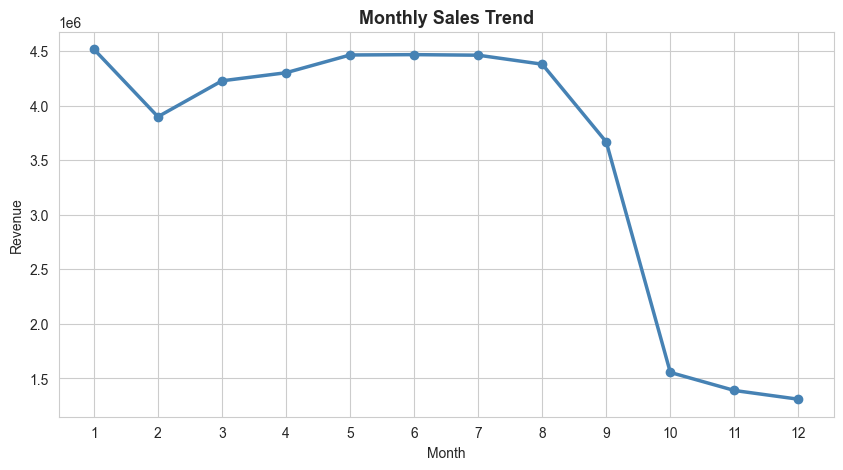

In [23]:
# Line Charts

sns.set_style('whitegrid')
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales['Month'], monthly_sales['Revenue'], marker='o', color='steelblue', linewidth=2.5)
plt.title('Monthly Sales Trend', fontsize=13, fontweight='bold')
plt.xlabel('Month') ; plt.ylabel('Revenue')
plt.xticks(range(1, 13))
plt.show()

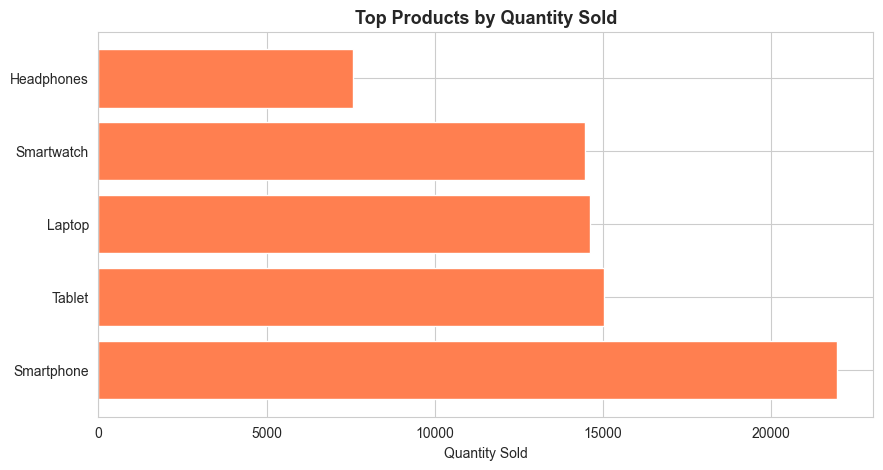

In [24]:
# Chart2 (Horizontal Bar)

plt.figure(figsize=(10, 5))
plt.barh(top_products_qty.index, top_products_qty.values, color='coral')
plt.title('Top Products by Quantity Sold', fontsize=13, fontweight='bold')
plt.xlabel('Quantity Sold')
plt.show()

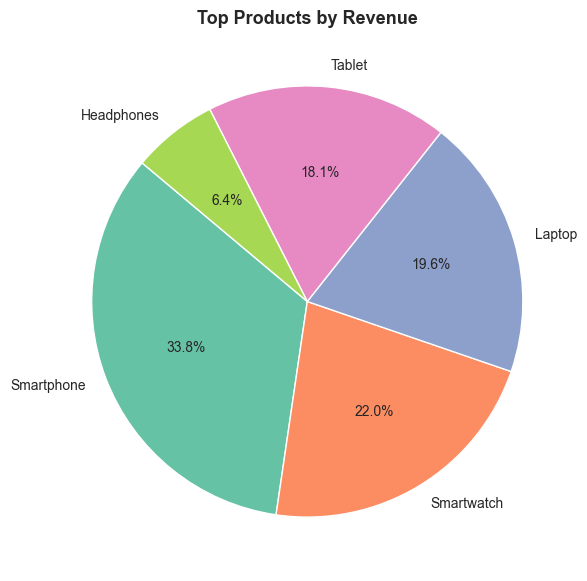

In [25]:

# Chart 3 (Pie)
plt.figure(figsize=(7, 7))
plt.pie(top_products_rev.values, labels=top_products_rev.index,
        autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'))
plt.title('Top Products by Revenue', fontsize=13, fontweight='bold')
plt.show()

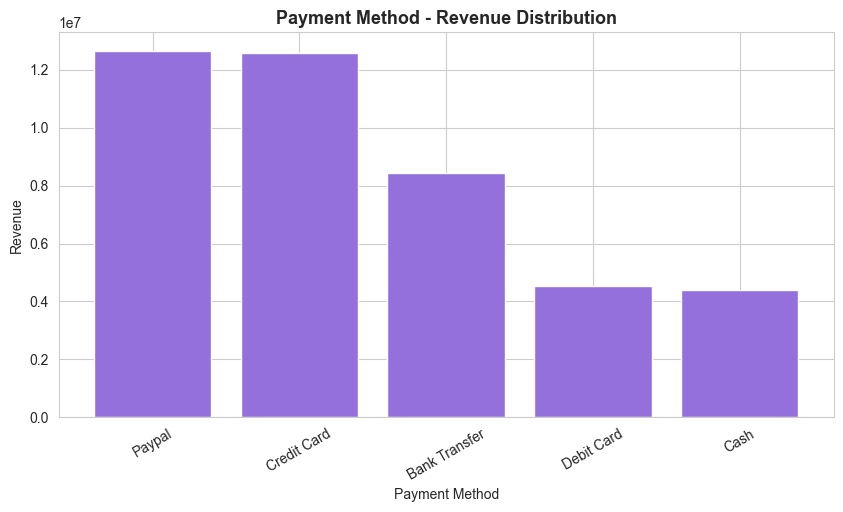

In [26]:
# Fix PayPal duplication first, then plot
payment_sales = (
    df.assign(Payment_Method=df['Payment_Method'].str.strip().str.title())
    .groupby('Payment_Method')['Total_Price']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
plt.bar(payment_sales.index, payment_sales.values, color='mediumpurple')
plt.title('Payment Method - Revenue Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Payment Method')
plt.ylabel('Revenue')
plt.xticks(rotation=30)
plt.show()


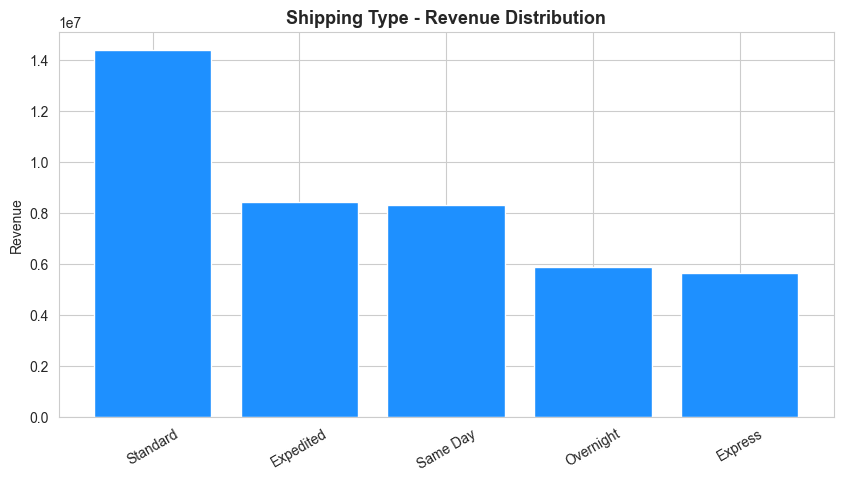

In [80]:

#Chart 5 (Bar)

plt.figure(figsize=(10, 5))
plt.bar(shipping_sales.index, shipping_sales.values, color='dodgerblue')
plt.title('Shipping Type - Revenue Distribution', fontsize=13, fontweight='bold')
plt.ylabel('Revenue') ; plt.xticks(rotation=30)
plt.show()

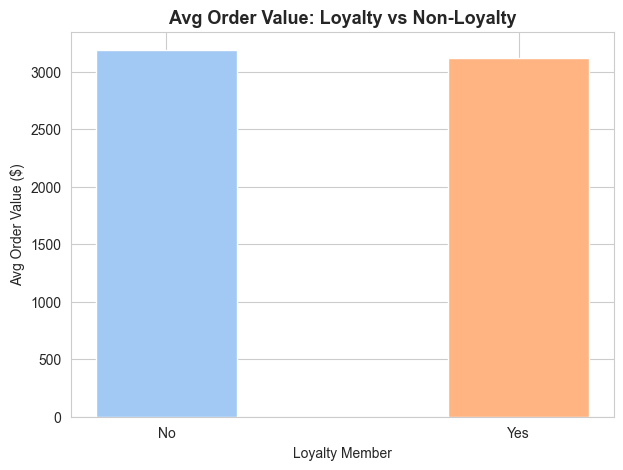

In [27]:
loyalty_avg = df.groupby('Loyalty_Member')['Total_Price'].mean()

plt.figure(figsize=(7, 5))
plt.bar(loyalty_avg.index, loyalty_avg.values, color=sns.color_palette('pastel'), width=0.4)
plt.title('Avg Order Value: Loyalty vs Non-Loyalty', fontsize=13, fontweight='bold')
plt.xlabel('Loyalty Member')
plt.ylabel('Avg Order Value ($)')
plt.show()

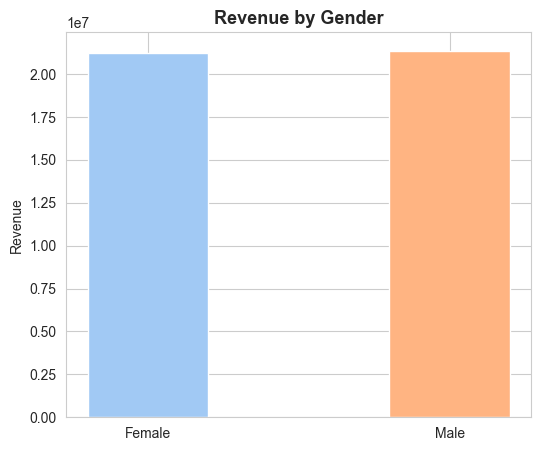

In [33]:
gender_rev = df.groupby('Gender')['Total_Price'].sum()

plt.figure(figsize=(6, 5))
plt.bar(gender_rev.index, gender_rev.values, color=sns.color_palette('pastel'), width=0.4)
plt.title('Revenue by Gender', fontsize=13, fontweight='bold')
plt.ylabel('Revenue')
plt.show()

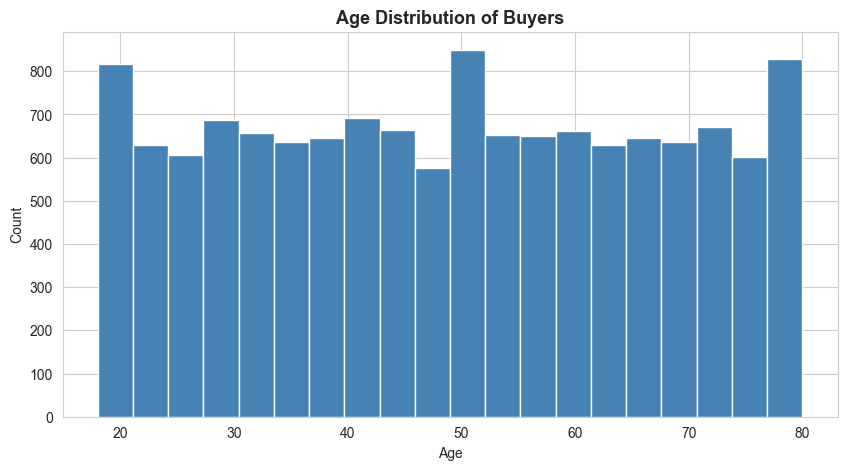

In [35]:
plt.figure(figsize=(10, 5))
plt.hist(df['Age'], bins=20, color='steelblue', edgecolor='white')
plt.title('Age Distribution of Buyers', fontsize=13, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

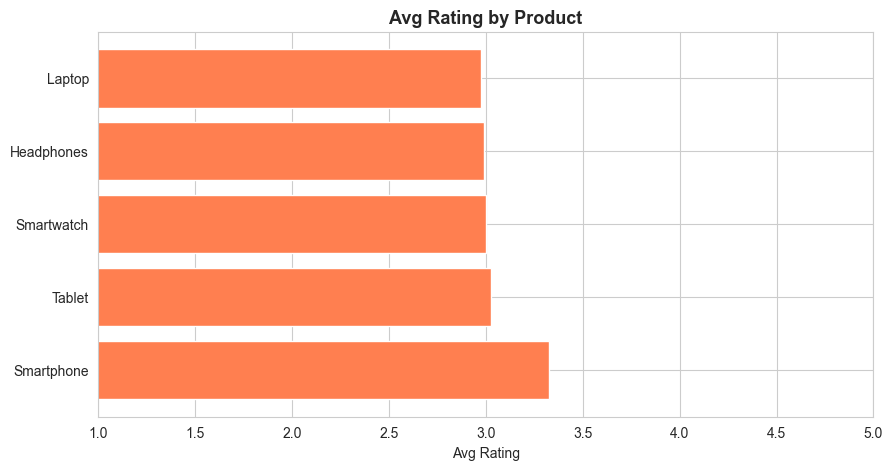

In [36]:
rating_avg = df.groupby('Product_Type')['Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(rating_avg.index, rating_avg.values, color='coral')
plt.title('Avg Rating by Product', fontsize=13, fontweight='bold')
plt.xlabel('Avg Rating')
plt.xlim(1, 5)
plt.show()

In [28]:
#Insights
peak_month = monthly_sales.loc[monthly_sales['Revenue'].idxmax(), 'Month']
peak_month

np.int32(1)

In [31]:
best_selling_product

'Smartphone'

In [30]:
top_revenue_product

'Smartphone'

In [32]:
avg_order_value

np.float64(3173.9216178988904)